# 03A: Modelling - Approach 1: Snapshot-based propensity

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
modelling_df = pd.read_csv('../processed/modelling_dataset.csv')
print(f"Shape: {modelling_df.shape}")

Shape: (83748, 37)


In [3]:
modelling_df.columns

Index(['customer_unique_id', 'num_orders', 'num_orders_approved',
       'num_orders_canceled', 'num_orders_created', 'num_orders_delivered',
       'num_orders_invoiced', 'num_orders_processing', 'num_orders_shipped',
       'num_orders_unavailable', 'total_payment_value',
       'total_payment_sequential', 'avg_payment_installments',
       'tot_pymt_boleto', 'tot_pymt_credit_card', 'tot_pymt_debit_card',
       'tot_pymt_voucher', 'num_products', 'num_sellers', 'avg_order_size',
       'tot_order_price', 'avg_order_price', 'tot_order_freight_value',
       'avg_order_freight_value', 'num_reviews', 'avg_review_score',
       'avg_review_title_length', 'avg_review_body_length',
       'days_since_last_purchase', 'days_since_last_shipped',
       'days_since_last_delivered', 'days_since_last_review',
       'pref_product_category', 'pref_payment_type', 'y_order_value',
       'y_propensity', 'y_order_value_log'],
      dtype='object')

# EDA

In [4]:
print("Null counts:")
print(modelling_df.isnull().sum()[modelling_df.isnull().sum() > 0])
print(f"\nShape: {modelling_df.shape}")
print(f"\nTarget distribution (y_propensity):")
print(modelling_df['y_propensity'].value_counts())
print(f"\nPositive rate: {modelling_df['y_propensity'].mean()*100:.3f}%")

Null counts:
Series([], dtype: int64)

Shape: (83748, 37)

Target distribution (y_propensity):
y_propensity
0    83455
1      293
Name: count, dtype: int64

Positive rate: 0.350%


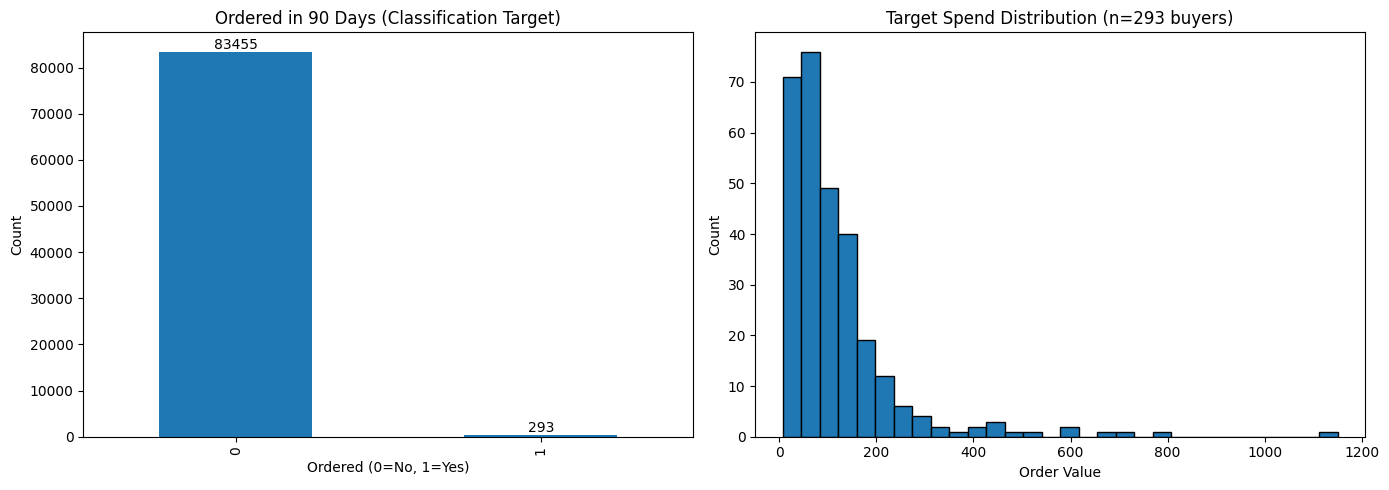

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution for classification target
modelling_df['y_propensity'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Ordered in 90 Days (Classification Target)')
axes[0].set_xlabel('Ordered (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
# Add count labels on bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()), ha='center', va='bottom')

# Spend distribution for regression target (only buyers)
buyers = modelling_df[modelling_df['y_order_value'] > 0]
axes[1].hist(buyers['y_order_value'], bins=30, edgecolor='black')
axes[1].set_title(f'Target Spend Distribution (n={len(buyers)} buyers)')
axes[1].set_xlabel('Order Value')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [6]:
modelling_df.dtypes

customer_unique_id            object
num_orders                     int64
num_orders_approved            int64
num_orders_canceled            int64
num_orders_created             int64
num_orders_delivered           int64
num_orders_invoiced            int64
num_orders_processing          int64
num_orders_shipped             int64
num_orders_unavailable         int64
total_payment_value          float64
total_payment_sequential     float64
avg_payment_installments     float64
tot_pymt_boleto              float64
tot_pymt_credit_card         float64
tot_pymt_debit_card          float64
tot_pymt_voucher             float64
num_products                   int64
num_sellers                    int64
avg_order_size               float64
tot_order_price              float64
avg_order_price              float64
tot_order_freight_value      float64
avg_order_freight_value      float64
num_reviews                    int64
avg_review_score             float64
avg_review_title_length      float64
a

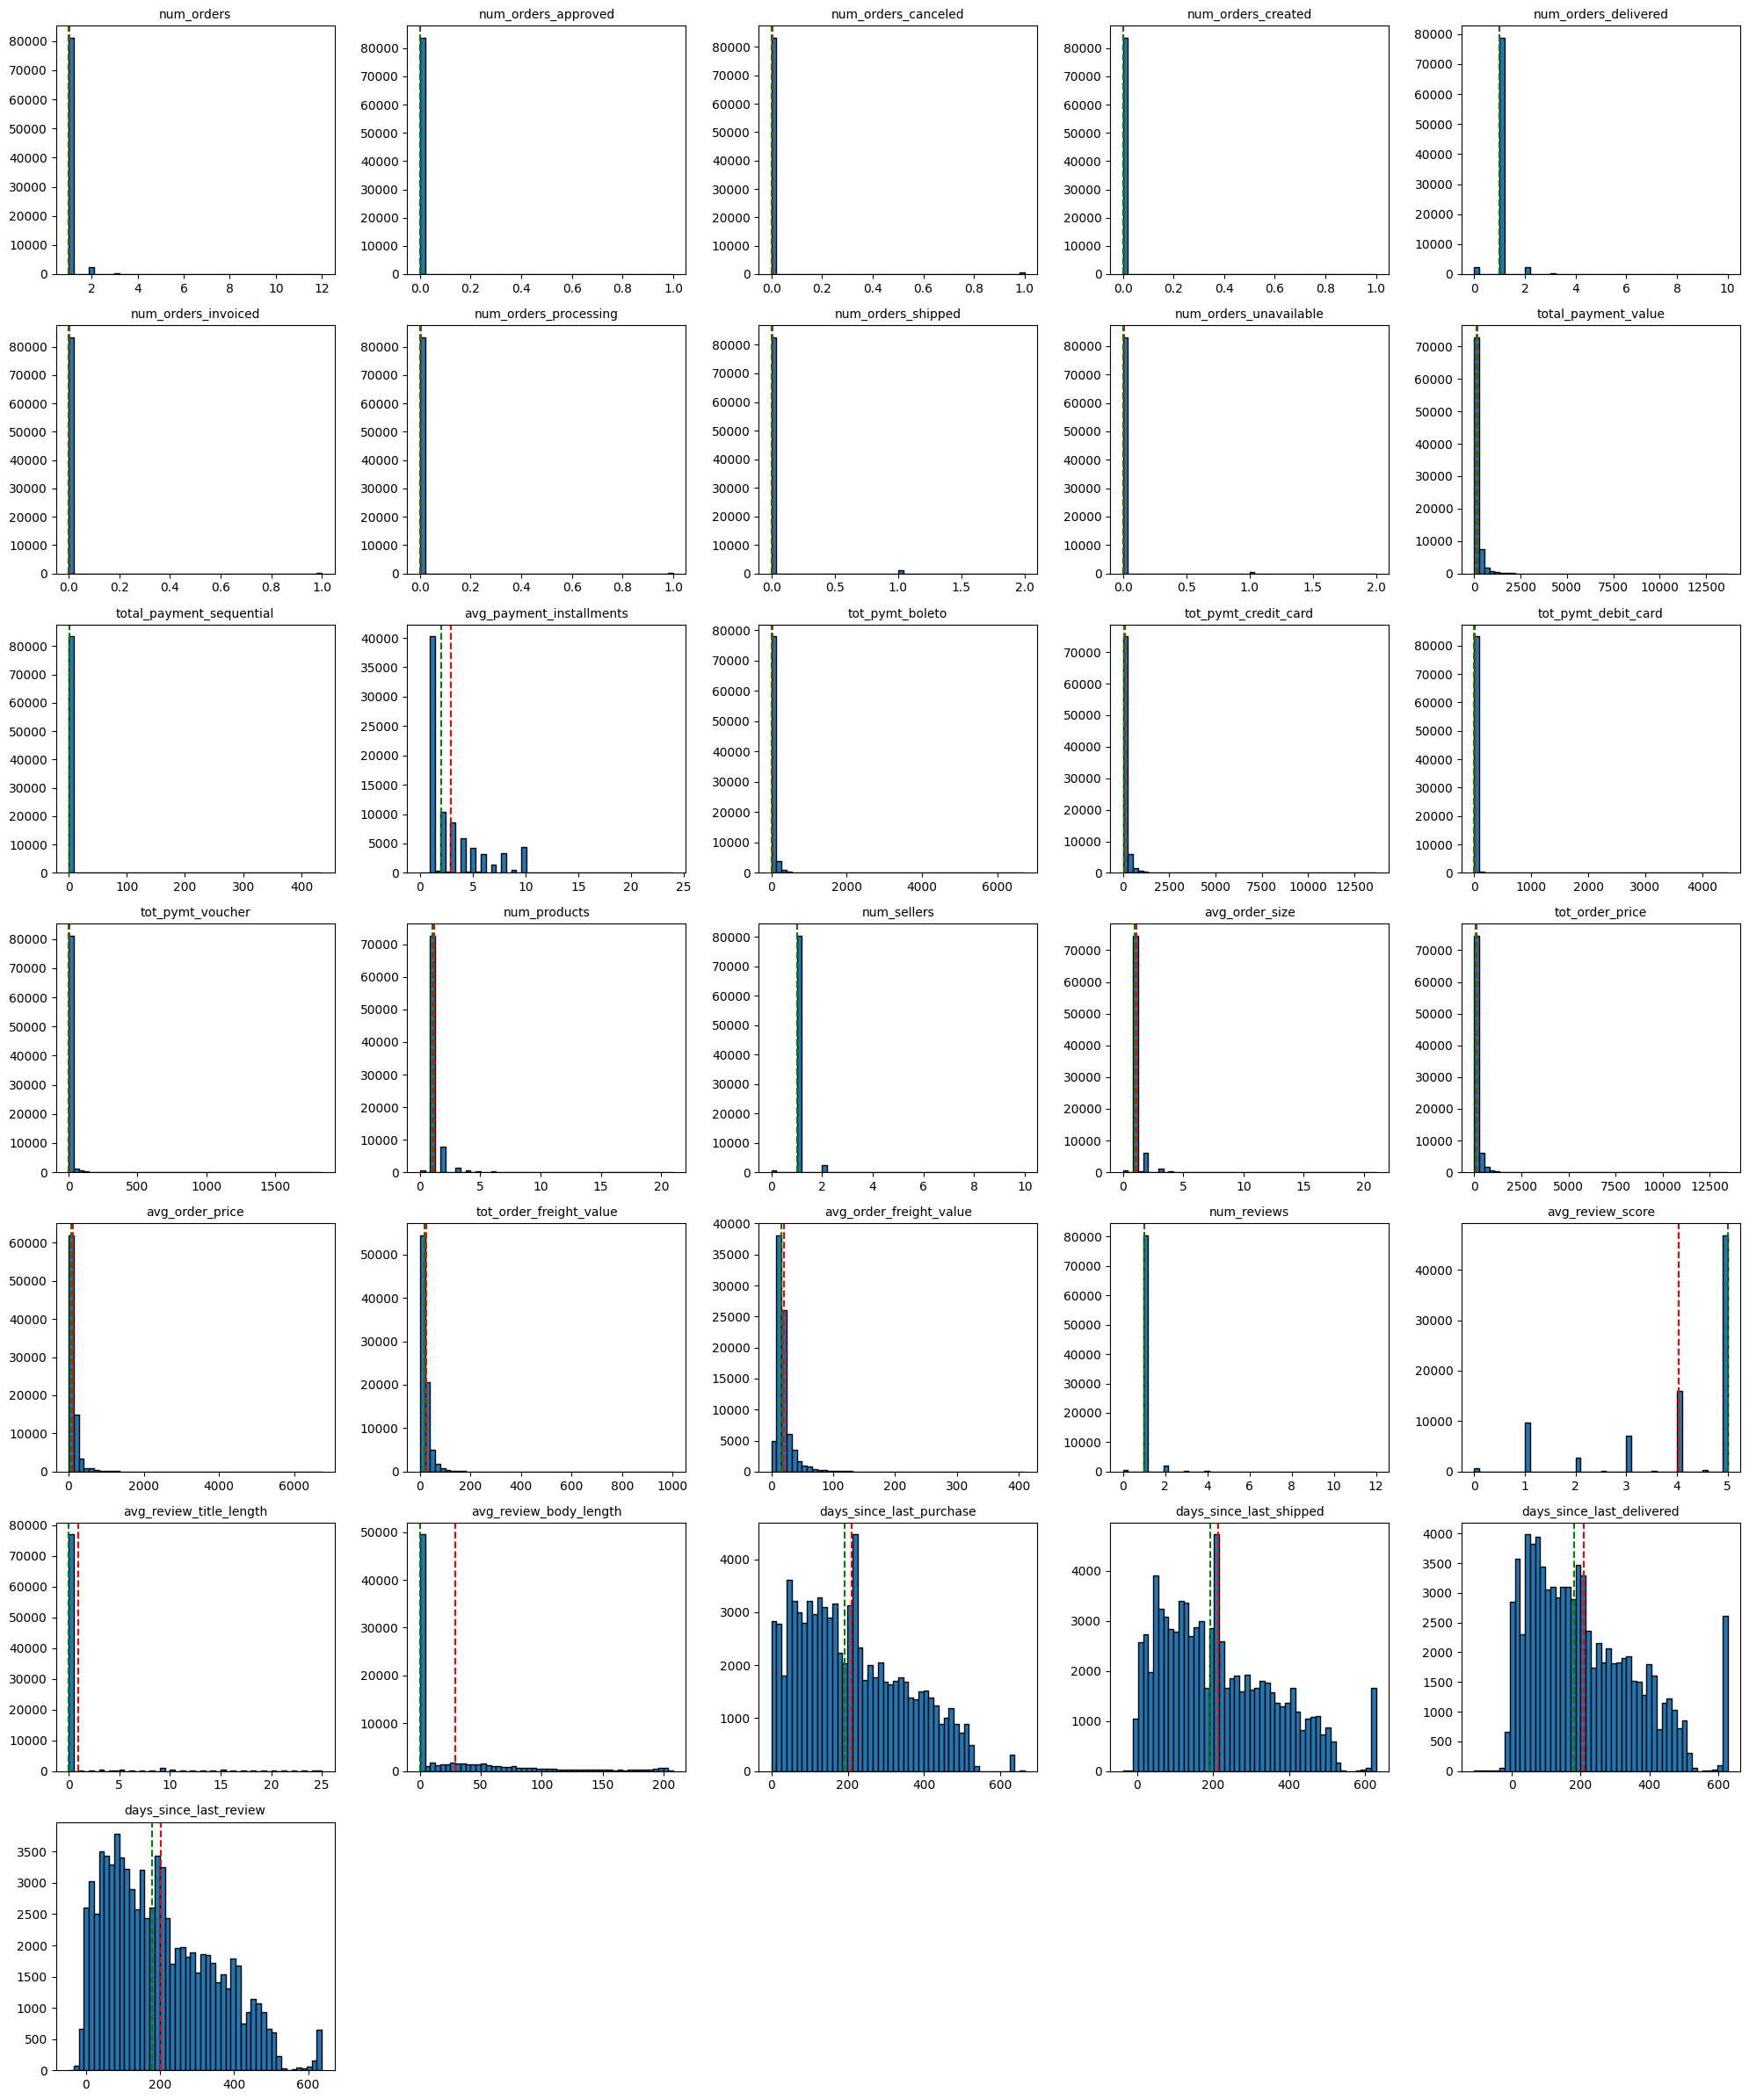

In [7]:
numeric_features = modelling_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features if col not in ['y_propensity', 'y_order_value', 'y_order_value_log']]

fig, axes = plt.subplots(7, 5, figsize=(20, 24))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(modelling_df[col], bins=50, edgecolor='black')
    axes[i].set_title(col, fontsize=10)
    axes[i].axvline(modelling_df[col].mean(), color='red', linestyle='--', label='mean')
    axes[i].axvline(modelling_df[col].median(), color='green', linestyle='--', label='median')

# Hide unused subplots
for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [9]:
numeric_cols = modelling_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['y_propensity', 'y_order_value', 'y_order_value_log']]

In [10]:
for col in numeric_cols:
    Q1 = modelling_df[col].quantile(0.25)
    Q3 = modelling_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = modelling_df[(modelling_df[col] < lower) | (modelling_df[col] > upper)]
    print(f"{col:25s} | IQR: {IQR:10.2f} | Bounds: [{lower:.2f}, {upper:.2f}] | Outliers: {len(outliers)} ({len(outliers)/len(modelling_df)*100:.2f}%)")

num_orders                | IQR:       0.00 | Bounds: [1.00, 1.00] | Outliers: 2574 (3.07%)
num_orders_approved       | IQR:       0.00 | Bounds: [0.00, 0.00] | Outliers: 2 (0.00%)
num_orders_canceled       | IQR:       0.00 | Bounds: [0.00, 0.00] | Outliers: 481 (0.57%)
num_orders_created        | IQR:       0.00 | Bounds: [0.00, 0.00] | Outliers: 5 (0.01%)
num_orders_delivered      | IQR:       0.00 | Bounds: [1.00, 1.00] | Outliers: 4909 (5.86%)
num_orders_invoiced       | IQR:       0.00 | Bounds: [0.00, 0.00] | Outliers: 278 (0.33%)
num_orders_processing     | IQR:       0.00 | Bounds: [0.00, 0.00] | Outliers: 300 (0.36%)
num_orders_shipped        | IQR:       0.00 | Bounds: [0.00, 0.00] | Outliers: 993 (1.19%)
num_orders_unavailable    | IQR:       0.00 | Bounds: [0.00, 0.00] | Outliers: 579 (0.69%)
total_payment_value       | IQR:     120.36 | Bounds: [-117.37, 364.07] | Outliers: 6659 (7.95%)
total_payment_sequential  | IQR:       0.00 | Bounds: [1.00, 1.00] | Outliers: 5105 (6

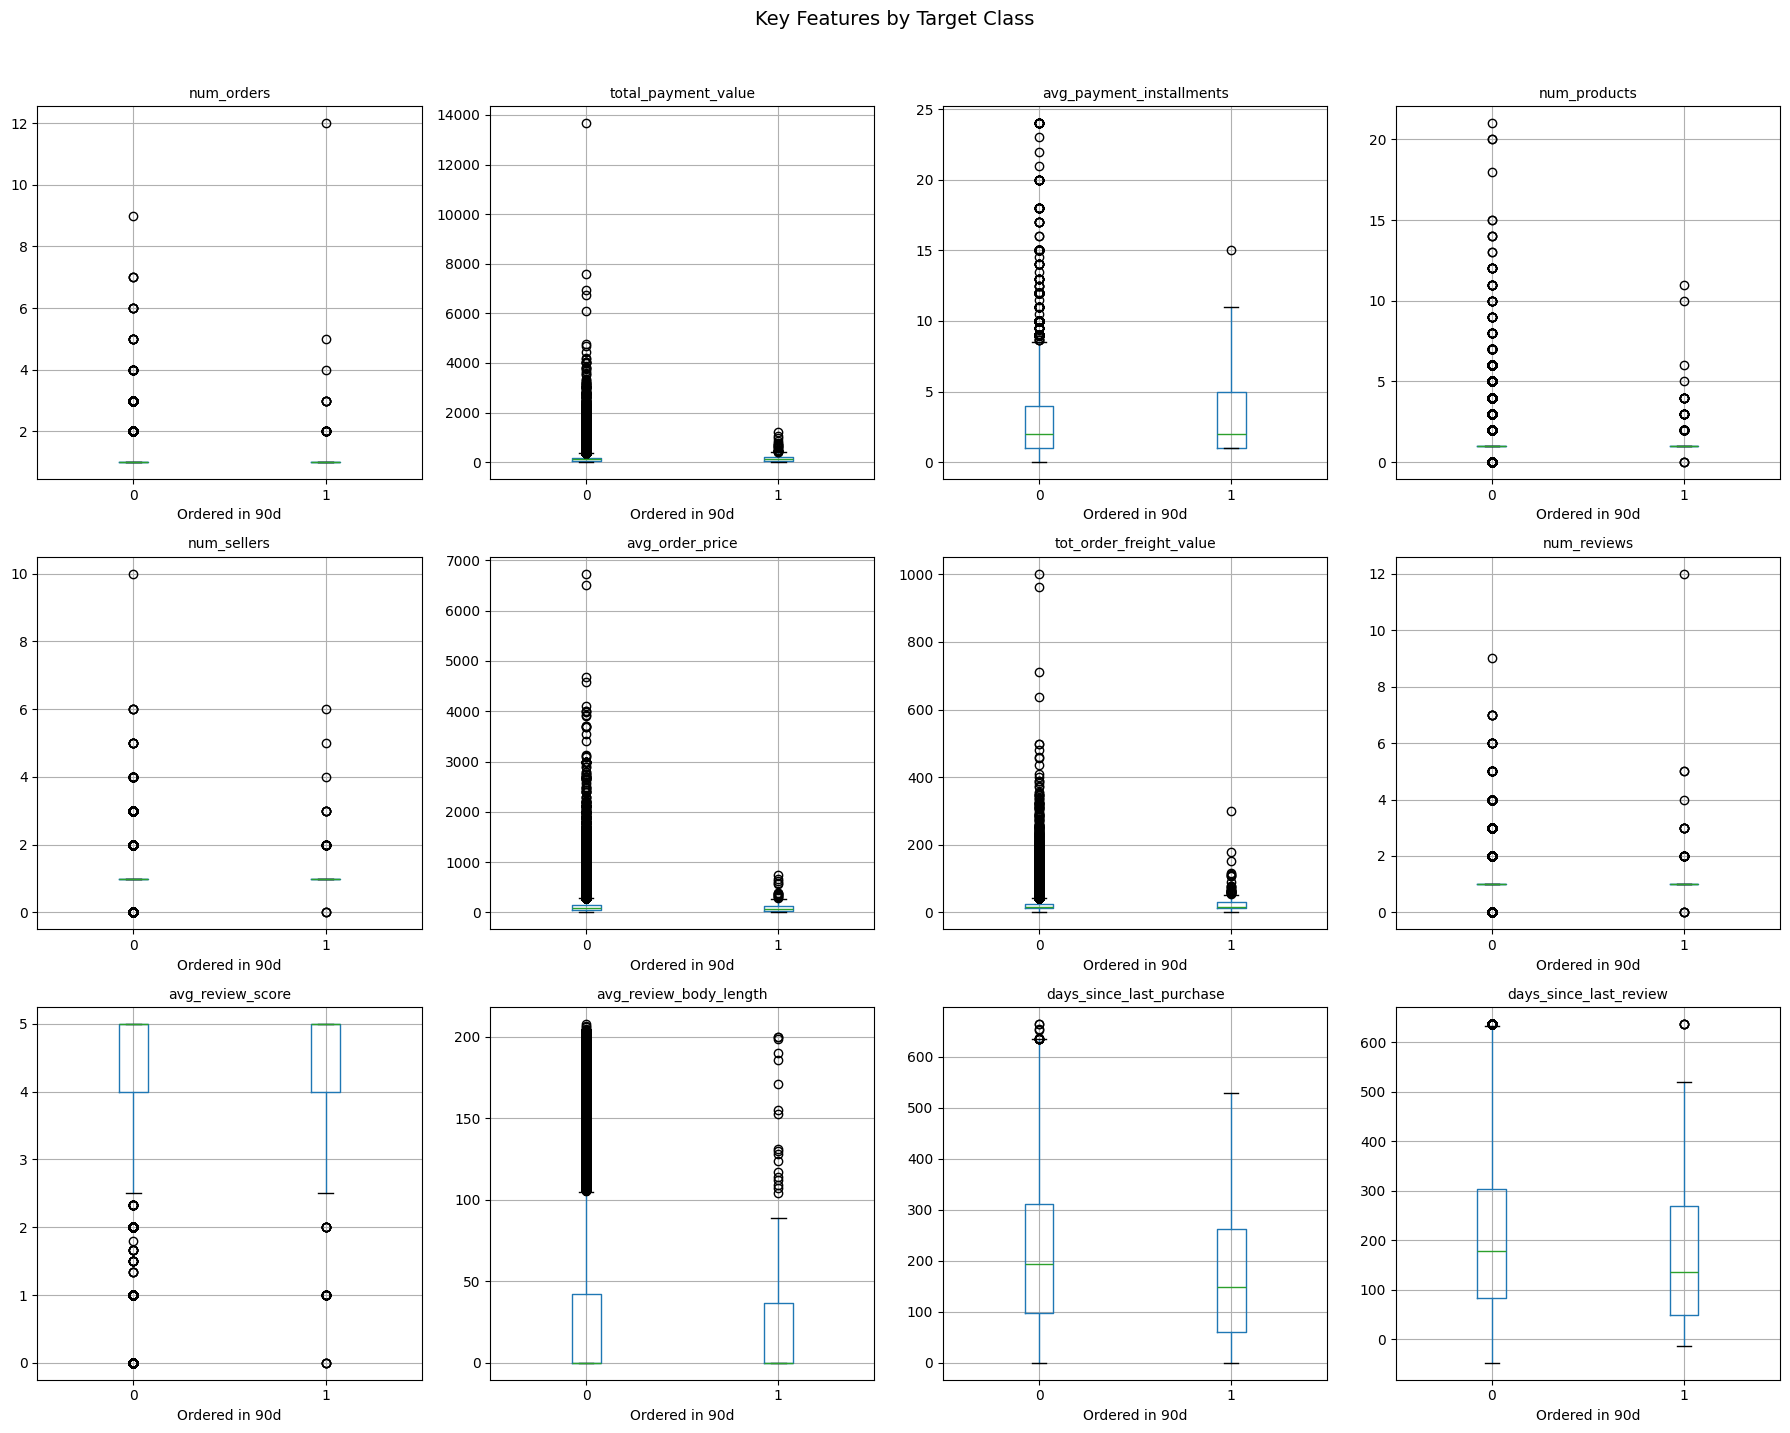

In [11]:
key_features = ['num_orders', 'total_payment_value', 'avg_payment_installments',
                'num_products', 'num_sellers', 'avg_order_price',
                'tot_order_freight_value', 'num_reviews', 'avg_review_score',
                'avg_review_body_length', 'days_since_last_purchase', 
                'days_since_last_review']

fig, axes = plt.subplots(3, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(key_features):
    modelling_df.boxplot(column=col, by='y_propensity', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Ordered in 90d')

plt.suptitle('Key Features by Target Class', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [12]:

corr_matrix = modelling_df[numeric_cols].corr()

# correlation > 0.7
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(corr_matrix.iloc[i, j], 3)))

print("Highly correlated pairs (|r| > 0.7):")
for pair in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {pair[0]:35s} ↔ {pair[1]:35s} r={pair[2]}")

Highly correlated pairs (|r| > 0.7):
  total_payment_value                 ↔ tot_order_price                     r=0.986
  days_since_last_purchase            ↔ days_since_last_review              r=0.961
  days_since_last_shipped             ↔ days_since_last_delivered           r=0.949
  days_since_last_purchase            ↔ days_since_last_shipped             r=0.943
  tot_order_price                     ↔ avg_order_price                     r=0.917
  num_products                        ↔ avg_order_size                      r=0.913
  days_since_last_shipped             ↔ days_since_last_review              r=0.905
  total_payment_value                 ↔ avg_order_price                     r=0.895
  days_since_last_purchase            ↔ days_since_last_delivered           r=0.894
  num_orders                          ↔ num_reviews                         r=0.88
  days_since_last_delivered           ↔ days_since_last_review              r=0.863
  total_payment_value                 ↔ 

### Feature Selection: Removing Highly Correlated Features

Computed pairwise Pearson correlation across all numeric features. Applied a threshold of **|r| > 0.7** to identify redundant pairs. From each pair, we drop the feature that is either less interpretable or a subset of the other.

**Dropped features and rationale:**

| Dropped Feature | Correlated With | r | Reason |
|---|---|---|---|
| `tot_order_price` | `total_payment_value` | 0.986 | Payment value is the actual amount paid; price is a subset |
| `days_since_last_review` | `days_since_last_purchase` | 0.961 | Purchase is the primary event; review follows it |
| `days_since_last_shipped` | `days_since_last_delivered` | 0.949 | Delivery is the customer-facing milestone |
| `avg_order_price` | `total_payment_value` | 0.895 | Redundant once total price is also dropped |
| `avg_order_size` | `num_products` | 0.913 | Total product count is more direct |
| `avg_order_freight_value` | `tot_order_freight_value` | 0.767 | Total freight is more informative |
| `num_orders_delivered` | `num_orders` | 0.756 | Total orders already captures this |

**Retained correlated pairs:** `num_orders` ↔ `num_reviews` (0.88) and `total_payment_value` ↔ `tot_pymt_credit_card` (0.86) — both pairs carry distinct business meaning (order frequency vs engagement; total spend vs payment channel preference).

In [13]:
drop_cols = ['tot_order_price', 'days_since_last_review', 'days_since_last_shipped',
             'avg_order_price', 'avg_order_size', 'avg_order_freight_value', 
             'num_orders_delivered']

modelling_df = modelling_df.drop(columns=drop_cols)
print(f"Shape after dropping correlated features: {modelling_df.shape}")

Shape after dropping correlated features: (83748, 30)


## EDA Summary

- **Class imbalance:** 0.35% positive rate (293 repeat buyers out of 83,748). Will use class weighting and PR-AUC as primary metric.
- **Feature distributions:** Most monetary and count features are heavily right-skewed due to 97% single-order users. Recency features show the best spread.
- **Predictive signals:** `days_since_last_purchase`, `days_since_last_delivered`, `avg_payment_installments`, and `num_products` show visible separation between classes.
- **Feature selection:** Removed 7 highly correlated features (|r| > 0.7), reducing from 37 to 30 columns.
- **Outliers:** Retained, represent real high-value customers. Tree-based models are robust to outliers.

## Categorical Encoding

In [14]:
# A. Group 'pref_product_category' into Top 10 + 'other'
top_10_categories = modelling_df['pref_product_category'].value_counts().head(10).index

modelling_df['pref_product_category'] = modelling_df['pref_product_category'].apply(
    lambda x: x if x in top_10_categories else 'other'
)

In [15]:
# B. One-Hot Encode both categorical columns
modelling_encoded = pd.get_dummies(
    modelling_df, 
    columns=['pref_product_category', 'pref_payment_type'],
    dtype=int
)

In [49]:
modelling_encoded.columns

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Index(['customer_unique_id', 'num_orders', 'num_orders_approved',
       'num_orders_canceled', 'num_orders_created', 'num_orders_invoiced',
       'num_orders_processing', 'num_orders_shipped', 'num_orders_unavailable',
       'total_payment_value', 'total_payment_sequential',
       'avg_payment_installments', 'tot_pymt_boleto', 'tot_pymt_credit_card',
       'tot_pymt_debit_card', 'tot_pymt_voucher', 'num_products',
       'num_sellers', 'tot_order_freight_value', 'num_reviews',
       'avg_review_score', 'avg_review_title_length', 'avg_review_body_length',
       'days_since_last_purchase', 'days_since_last_delivered',
       'y_order_value', 'y_propensity', 'y_order_value_log',
       'pref_product_category_bed_bath_table',
       'pref_product_category_computers_accessories',
       'pref_product_category_cool_stuff',
       'pref_product_category_furniture_decor',
       'pref_product_category_health_beauty',
       'pref_product_category_housewares', 'pref_product_category_othe

In [50]:
modelling_encoded.shape

(83748, 44)

## Data Split

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
# Drop the IDs and Target variables from our feature set
cols_to_drop = ['customer_unique_id', 'y_propensity', 'y_order_value', 'y_order_value_log']
X = modelling_encoded.drop(columns=cols_to_drop)

# Isolate our targets
y_propensity = modelling_encoded['y_propensity']
y_value_log = modelling_encoded['y_order_value_log']


X_train, X_test, y_train_prop, y_test_prop = train_test_split(
    X, 
    y_propensity, 
    test_size=0.20,     
    random_state=42,     
    stratify=y_propensity 
)

y_train_value = y_value_log.loc[y_train_prop.index]
y_test_value = y_value_log.loc[y_test_prop.index]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("-" * 30)
print("Propensity Balance in Train:")
print(y_train_prop.value_counts(normalize=True))
print("Propensity Balance in Test:")
print(y_test_prop.value_counts(normalize=True))

X_train shape: (66998, 40)
X_test shape: (16750, 40)
------------------------------
Propensity Balance in Train:
y_propensity
0    0.996507
1    0.003493
Name: proportion, dtype: float64
Propensity Balance in Test:
y_propensity
0    0.996478
1    0.003522
Name: proportion, dtype: float64


# Modelling

In [19]:
results = {}

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

## Logistic Regression

### Feature Scaling
StandardScaler applied for Logistic Regression only. Tree-based models (Random Forest, XGBoost) are scale-invariant and use unscaled features.

In [21]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [22]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=10000, solver='saga', random_state=42)
lr_model.fit(X_train_scaled, y_train_prop)
y_scores_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

results['Logistic Regression'] = {
    'roc_auc': roc_auc_score(y_test_prop, y_scores_lr),
    'pr_auc': average_precision_score(y_test_prop, y_scores_lr),
    'y_scores': y_scores_lr
}
print(f"Logistic Regression — ROC-AUC: {results['Logistic Regression']['roc_auc']:.4f}, PR-AUC: {results['Logistic Regression']['pr_auc']:.4f}")

Logistic Regression — ROC-AUC: 0.5974, PR-AUC: 0.0063


In [23]:
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced', None],
    'solver': ['saga'],
    'max_iter': [5000, 10000, 15000]
}

lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid,
    n_iter=20,
    scoring='average_precision',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
lr_search.fit(X_train_scaled, y_train_prop)

print(f"Best params: {lr_search.best_params_}")
print(f"Best CV PR-AUC: {lr_search.best_score_:.4f}")

y_scores_lr = lr_search.best_estimator_.predict_proba(X_test_scaled)[:, 1]
results = {}
results['Logistic Regression'] = {
    'best_params': lr_search.best_params_,
    'cv_pr_auc': lr_search.best_score_,
    'test_roc_auc': roc_auc_score(y_test_prop, y_scores_lr),
    'test_pr_auc': average_precision_score(y_test_prop, y_scores_lr),
    'y_scores': y_scores_lr
}
print(f"Test ROC-AUC: {results['Logistic Regression']['test_roc_auc']:.4f}")
print(f"Test PR-AUC: {results['Logistic Regression']['test_pr_auc']:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/ujwaljibhkate/Projects/SCOWTT/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ujwaljibhkate/Projects/SCOWTT/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ujwaljibhkate/Projects/SCOWTT/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2

Best params: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 10000, 'class_weight': None, 'C': 1}
Best CV PR-AUC: 0.0137
Test ROC-AUC: 0.5995
Test PR-AUC: 0.0061


## Random forest

In [24]:
rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [1, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample', None],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    n_iter=30,
    scoring='average_precision',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train_prop)

print(f"\nBest params: {rf_search.best_params_}")
print(f"Best CV PR-AUC: {rf_search.best_score_:.4f}")

# Predict on the test set
y_scores_rf = rf_search.best_estimator_.predict_proba(X_test)[:, 1]

results['Random Forest'] = {
    'best_params': rf_search.best_params_,
    'cv_pr_auc': rf_search.best_score_,
    'test_roc_auc': roc_auc_score(y_test_prop, y_scores_rf),
    'test_pr_auc': average_precision_score(y_test_prop, y_scores_rf),
    'y_scores': y_scores_rf
}

print(f"Test ROC-AUC: {results['Random Forest']['test_roc_auc']:.4f}")
print(f"Test PR-AUC: {results['Random Forest']['test_pr_auc']:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 3, 'class_weight': None}
Best CV PR-AUC: 0.0089
Test ROC-AUC: 0.6040
Test PR-AUC: 0.0063


In [25]:
from xgboost import XGBClassifier

scale_ratio = int(len(y_train_prop[y_train_prop == 0]) / len(y_train_prop[y_train_prop == 1]))

xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'scale_pos_weight': [1, 50, 100, scale_ratio],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='aucpr', n_jobs=-1),
    xgb_param_grid,
    n_iter=50,
    scoring='average_precision',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train, y_train_prop)

print(f"\nBest params: {xgb_search.best_params_}")
print(f"Best CV PR-AUC: {xgb_search.best_score_:.4f}")

# Predict on the test set
y_scores_xgb = xgb_search.best_estimator_.predict_proba(X_test)[:, 1]

results['XGB'] = {
    'best_params': xgb_search.best_params_,
    'cv_pr_auc': xgb_search.best_score_,
    'test_roc_auc': roc_auc_score(y_test_prop, y_scores_xgb),
    'test_pr_auc': average_precision_score(y_test_prop, y_scores_xgb),
    'y_scores': y_scores_xgb
}

print(f"Test ROC-AUC: {results['XGB']['test_roc_auc']:.4f}")
print(f"Test PR-AUC: {results['XGB']['test_pr_auc']:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best params: {'subsample': 0.7, 'scale_pos_weight': 1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV PR-AUC: 0.0067
Test ROC-AUC: 0.5970
Test PR-AUC: 0.0066


In [26]:
print("\n" + "="*60)
print("CLASSIFICATION MODEL COMPARISON — Purchase Propensity")
print("="*60)
for name, res in results.items():
    print(f"\n{name}:")
    print(f"  Best Params: {res['best_params']}")
    print(f"  CV PR-AUC:   {res['cv_pr_auc']:.4f}")
    print(f"  Test ROC-AUC: {res['test_roc_auc']:.4f}")
    print(f"  Test PR-AUC:  {res['test_pr_auc']:.4f}")


CLASSIFICATION MODEL COMPARISON — Purchase Propensity

Logistic Regression:
  Best Params: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 10000, 'class_weight': None, 'C': 1}
  CV PR-AUC:   0.0137
  Test ROC-AUC: 0.5995
  Test PR-AUC:  0.0061

Random Forest:
  Best Params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 3, 'class_weight': None}
  CV PR-AUC:   0.0089
  Test ROC-AUC: 0.6040
  Test PR-AUC:  0.0063

XGB:
  Best Params: {'subsample': 0.7, 'scale_pos_weight': 1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
  CV PR-AUC:   0.0067
  Test ROC-AUC: 0.5970
  Test PR-AUC:  0.0066


In [27]:
from imblearn.ensemble import BalancedRandomForestClassifier

brf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5, 0.7],
    'sampling_strategy': ['all', 'majority'],
}

brf_search = RandomizedSearchCV(
    BalancedRandomForestClassifier(random_state=42, n_jobs=-1),
    brf_param_grid,
    n_iter=50,
    scoring='average_precision',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
brf_search.fit(X_train, y_train_prop)


print(f"\nBest params: {brf_search.best_params_}")
print(f"Best CV PR-AUC: {brf_search.best_score_:.4f}")

# Predict on the test set
y_scores_brf = brf_search.best_estimator_.predict_proba(X_test)[:, 1]

results['Balanced Random Forest'] = {
    'best_params': brf_search.best_params_,
    'cv_pr_auc': brf_search.best_score_,
    'test_roc_auc': roc_auc_score(y_test_prop, y_scores_brf),
    'test_pr_auc': average_precision_score(y_test_prop, y_scores_brf),
    'y_scores': y_scores_brf
}

print(f"Test ROC-AUC: {results['Balanced Random Forest']['test_roc_auc']:.4f}")
print(f"Test PR-AUC: {results['Balanced Random Forest']['test_pr_auc']:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best params: {'sampling_strategy': 'majority', 'n_estimators': 100, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 7}
Best CV PR-AUC: 0.0087
Test ROC-AUC: 0.6171
Test PR-AUC: 0.0077


In [28]:
!uv add lightgbm

Resolved 169 packages in 12ms
Audited 146 packages in 33ms


In [29]:
from lightgbm import LGBMClassifier

lgbm_param_grid = {
    'n_estimators': [100, 200, 300, 500, 800],
    'max_depth': [3, 4, 5, 6, -1],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [15, 31, 50, 70],
    'min_child_samples': [5, 10, 20, 50],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'is_unbalance': [True, False],
    'scale_pos_weight': [1, 50, 100],
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1),
    lgbm_param_grid,
    n_iter=50,
    scoring='average_precision',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
lgbm_search.fit(X_train, y_train_prop)

print(f"\nBest params: {lgbm_search.best_params_}")
print(f"Best CV PR-AUC: {lgbm_search.best_score_:.4f}")

# Predict on the test set
y_scores_lgbm = lgbm_search.best_estimator_.predict_proba(X_test)[:, 1]

results['LightGBM'] = {
    'best_params': lgbm_search.best_params_,
    'cv_pr_auc': lgbm_search.best_score_,
    'test_roc_auc': roc_auc_score(y_test_prop, y_scores_lgbm),
    'test_pr_auc': average_precision_score(y_test_prop, y_scores_lgbm),
    'y_scores': y_scores_lgbm
}

print(f"Test ROC-AUC: {results['LightGBM']['test_roc_auc']:.4f}")
print(f"Test PR-AUC: {results['LightGBM']['test_pr_auc']:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits


[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot se


Best params: {'subsample': 0.7, 'scale_pos_weight': 100, 'num_leaves': 31, 'n_estimators': 100, 'min_child_samples': 5, 'max_depth': 3, 'learning_rate': 0.05, 'is_unbalance': False, 'colsample_bytree': 0.7}
Best CV PR-AUC: 0.0058
Test ROC-AUC: 0.6044
Test PR-AUC: 0.0073


In [30]:
# What percentage of our 293 positive users had MORE than 1 order in the feature window?
positive_users = modelling_df[modelling_df['y_propensity'] == 1]['customer_unique_id']
print("Positive users - num_orders distribution:")
print(modelling_df[modelling_df['y_propensity'] == 1]['num_orders'].describe())
print("\nNegative users - num_orders distribution:")
print(modelling_df[modelling_df['y_propensity'] == 0]['num_orders'].describe())
print("\n% of positive users with >1 order:", 
      (modelling_df[modelling_df['y_propensity'] == 1]['num_orders'] > 1).mean() * 100)
print("% of negative users with >1 order:", 
      (modelling_df[modelling_df['y_propensity'] == 0]['num_orders'] > 1).mean() * 100)

Positive users - num_orders distribution:
count    293.000000
mean       1.174061
std        0.785404
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       12.000000
Name: num_orders, dtype: float64

Negative users - num_orders distribution:
count    83455.000000
mean         1.033767
std          0.205458
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          9.000000
Name: num_orders, dtype: float64

% of positive users with >1 order: 10.580204778156997
% of negative users with >1 order: 3.047151159307411


In [31]:
print("\n" + "="*60)
print("CLASSIFICATION MODEL COMPARISON — Purchase Propensity")
print("="*60)
for name, res in results.items():
    print(f"\n{name}:")
    print(f"  Best Params: {res['best_params']}")
    print(f"  CV PR-AUC:   {res['cv_pr_auc']}")
    print(f"  Test ROC-AUC: {res['test_roc_auc']:.4f}")
    print(f"  Test PR-AUC:  {res['test_pr_auc']:.4f}")


CLASSIFICATION MODEL COMPARISON — Purchase Propensity

Logistic Regression:
  Best Params: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 10000, 'class_weight': None, 'C': 1}
  CV PR-AUC:   0.013666673164052873
  Test ROC-AUC: 0.5995
  Test PR-AUC:  0.0061

Random Forest:
  Best Params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 3, 'class_weight': None}
  CV PR-AUC:   0.008904125613291583
  Test ROC-AUC: 0.6040
  Test PR-AUC:  0.0063

XGB:
  Best Params: {'subsample': 0.7, 'scale_pos_weight': 1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
  CV PR-AUC:   0.0067389741045012
  Test ROC-AUC: 0.5970
  Test PR-AUC:  0.0066

Balanced Random Forest:
  Best Params: {'sampling_strategy': 'majority', 'n_estimators': 100, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 7}
  CV PR-AUC:   0.008695503186928228
  Test ROC-AUC: 0.6171
  Test PR-AUC:  0.0077

LightGBM:
  Best Params: {'subsample': 0.7, 'scale_p

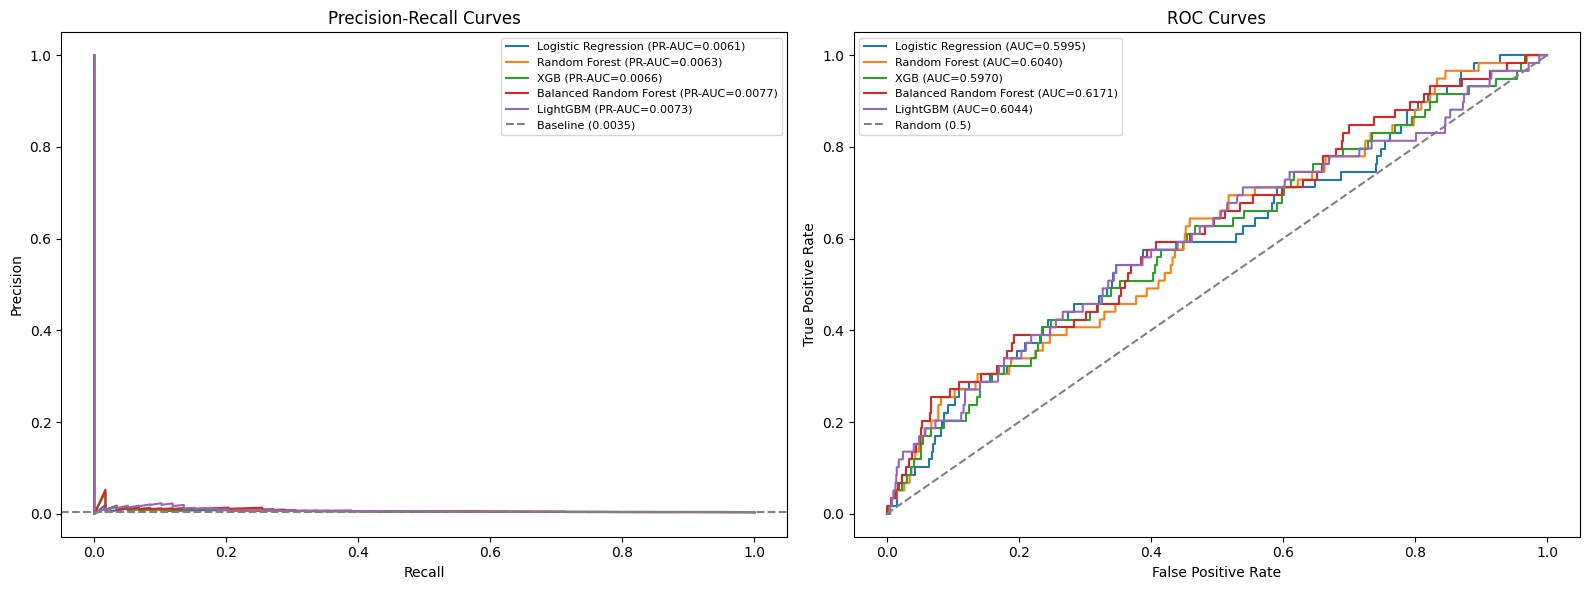

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PR Curves
for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test_prop, res['y_scores'])
    axes[0].plot(recall, precision, label=f"{name} (PR-AUC={res['test_pr_auc']:.4f})")

axes[0].axhline(y=y_test_prop.mean(), color='gray', linestyle='--', label=f"Baseline ({y_test_prop.mean():.4f})")
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves')
axes[0].legend(fontsize=8)

# Plot 2: ROC Curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test_prop, res['y_scores'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['test_roc_auc']:.4f})")

axes[1].plot([0,1], [0,1], color='gray', linestyle='--', label='Random (0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

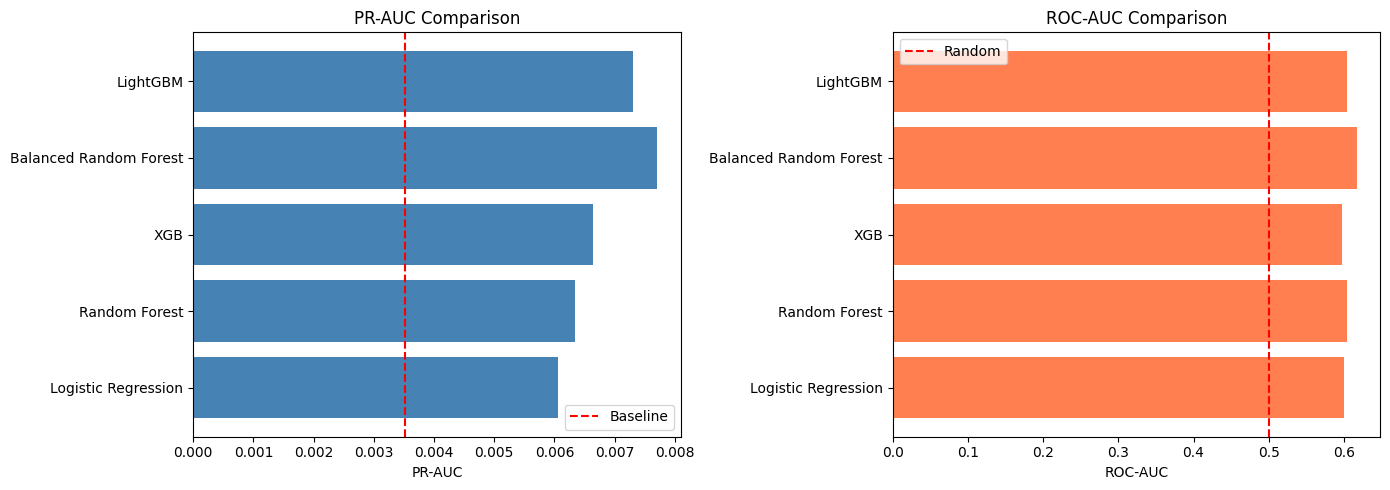

In [33]:
# Model Comparison Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(results.keys())
pr_aucs = [results[m]['test_pr_auc'] for m in model_names]
roc_aucs = [results[m]['test_roc_auc'] for m in model_names]

axes[0].barh(model_names, pr_aucs, color='steelblue')
axes[0].set_xlabel('PR-AUC')
axes[0].set_title('PR-AUC Comparison')
axes[0].axvline(x=y_test_prop.mean(), color='red', linestyle='--', label='Baseline')
axes[0].legend()

axes[1].barh(model_names, roc_aucs, color='coral')
axes[1].set_xlabel('ROC-AUC')
axes[1].set_title('ROC-AUC Comparison')
axes[1].axvline(x=0.5, color='red', linestyle='--', label='Random')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

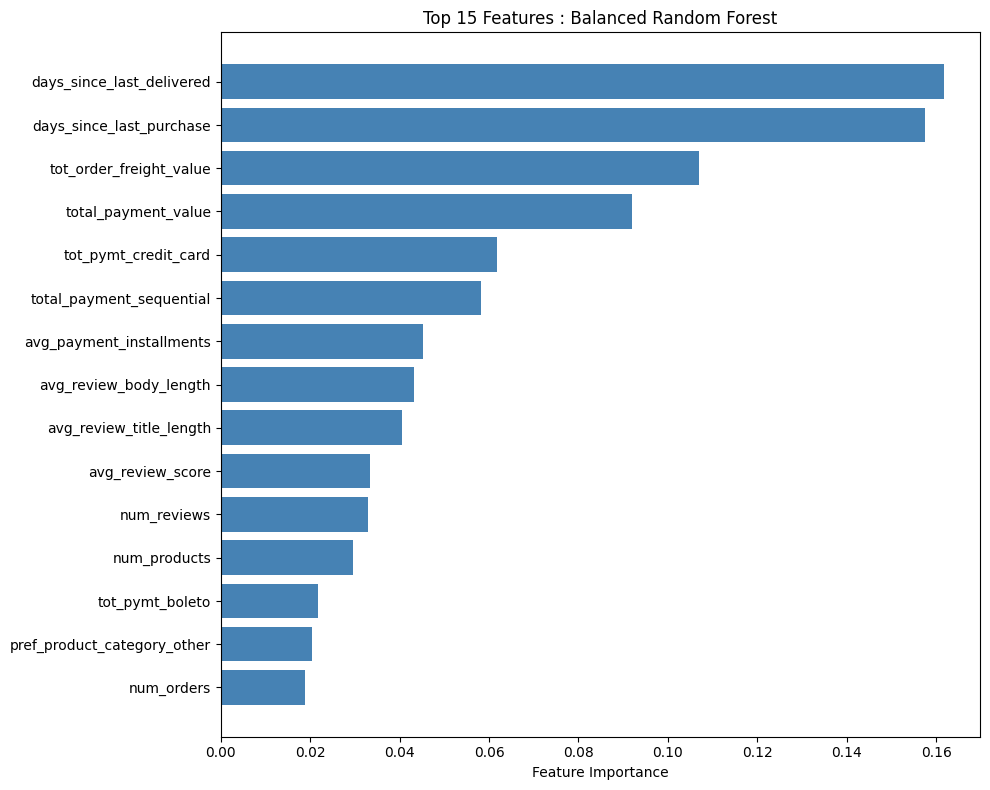

In [35]:
# Feature Importance from Balanced Random Forest
best_model = brf_search.best_estimator_
importances = best_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features : Balanced Random Forest')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
import joblib

best_classifier = brf_search.best_estimator_
joblib.dump(best_classifier, '../outputs/best_propensity_model.pkl')
joblib.dump(scaler, '../outputs/scaler.pkl')

['../outputs/scaler.pkl']

# Regression Task

In [37]:
# Filter to only buyers for regression training
buyer_mask_train = y_train_prop == 1
buyer_mask_test = y_test_prop == 1

X_train_reg = X_train[buyer_mask_train]
X_test_reg = X_test[buyer_mask_test]
y_train_reg = y_train_value[buyer_mask_train]
y_test_reg = y_test_value[buyer_mask_test]

print(f"Regression train size: {X_train_reg.shape[0]}")
print(f"Regression test size: {X_test_reg.shape[0]}")

Regression train size: 234
Regression test size: 59


In [38]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

reg_results = {}

In [39]:
## Ridge

In [40]:
ridge_param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'solver': ['auto', 'svd', 'lsqr']
}

ridge_search = RandomizedSearchCV(
    Ridge(), ridge_param_grid, n_iter=15, scoring='neg_mean_absolute_error',
    cv=3, random_state=42, n_jobs=-1
)

ridge_search.fit(X_train_reg, y_train_reg)

y_pred_ridge = ridge_search.best_estimator_.predict(X_test_reg)
reg_results['Ridge'] = {
    'best_params': ridge_search.best_params_,
    'mae': mean_absolute_error(np.expm1(y_test_reg), np.expm1(y_pred_ridge)),
    'rmse': np.sqrt(mean_squared_error(np.expm1(y_test_reg), np.expm1(y_pred_ridge)))
}

print(f"Test MAE: {reg_results['Ridge']['mae']:.4f}")
print(f"Test RMSE: {reg_results['Ridge']['rmse']:.4f}")

Test MAE: 60.2392
Test RMSE: 94.3821


In [41]:
# Random Forest sweep
rf_reg_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0]
}
rf_reg_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42), rf_reg_param_grid, n_iter=30,
    scoring='neg_mean_absolute_error', cv=3, random_state=42, n_jobs=-1
)
rf_reg_search.fit(X_train_reg, y_train_reg)
y_pred_rf = rf_reg_search.best_estimator_.predict(X_test_reg)
reg_results['Random Forest'] = {
    'best_params': rf_reg_search.best_params_,
    'mae': mean_absolute_error(np.expm1(y_test_reg), np.expm1(y_pred_rf)),
    'rmse': np.sqrt(mean_squared_error(np.expm1(y_test_reg), np.expm1(y_pred_rf)))
}

print(f"Test MAE: {reg_results['Random Forest']['mae']:.4f}")
print(f"Test RMSE: {reg_results['Random Forest']['rmse']:.4f}")

Test MAE: 55.7549
Test RMSE: 91.7989


In [42]:
# XGBoost sweep
xgb_reg_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}
xgb_reg_search = RandomizedSearchCV(
    XGBRegressor(random_state=42), xgb_reg_param_grid, n_iter=30,
    scoring='neg_mean_absolute_error', cv=3, random_state=42, n_jobs=-1
)
xgb_reg_search.fit(X_train_reg, y_train_reg)
y_pred_xgb = xgb_reg_search.best_estimator_.predict(X_test_reg)
reg_results['XGBoost'] = {
    'best_params': xgb_reg_search.best_params_,
    'mae': mean_absolute_error(np.expm1(y_test_reg), np.expm1(y_pred_xgb)),
    'rmse': np.sqrt(mean_squared_error(np.expm1(y_test_reg), np.expm1(y_pred_xgb)))
}

print(f"Test MAE: {reg_results['XGBoost']['mae']:.4f}")
print(f"Test RMSE: {reg_results['XGBoost']['rmse']:.4f}")

Test MAE: 55.7817
Test RMSE: 92.1432


In [44]:
print("="*50)
print("REGRESSION MODEL COMPARISON: Order Value")
print("="*50)
for name, res in reg_results.items():
    print(f"\n{name}:")
    print(f"  Best Params: {res['best_params']}")
    print(f"  MAE:  {res['mae']:.2f}")
    print(f"  RMSE: {res['rmse']:.2f}")

REGRESSION MODEL COMPARISON: Order Value

Ridge:
  Best Params: {'solver': 'lsqr', 'alpha': 100}
  MAE:  60.24
  RMSE: 94.38

Random Forest:
  Best Params: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 1.0, 'max_depth': 3}
  MAE:  55.75
  RMSE: 91.80

XGBoost:
  Best Params: {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
  MAE:  55.78
  RMSE: 92.14


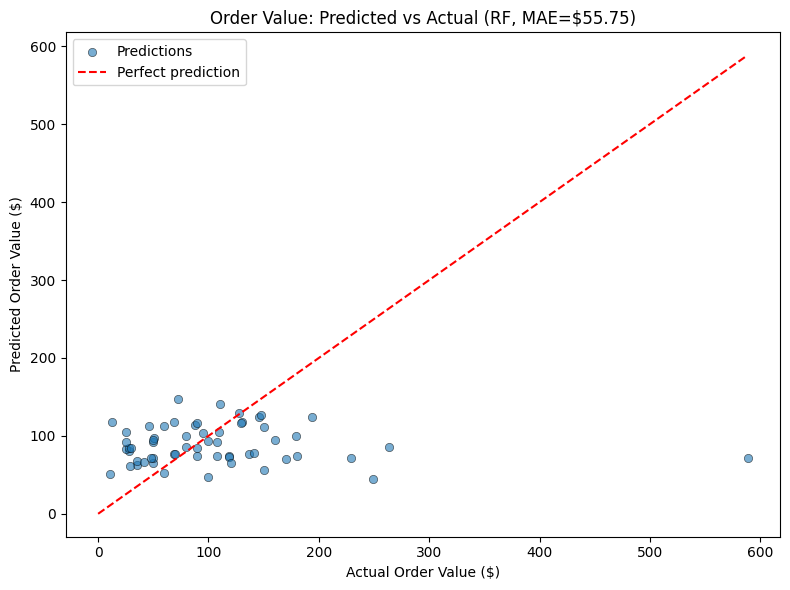

In [48]:
# Scatter plot: Predicted vs Actual (best model - Random Forest)
fig, ax = plt.subplots(figsize=(8, 6))

actual = np.expm1(y_test_reg)
predicted = np.expm1(y_pred_rf)

ax.scatter(actual, predicted, alpha=0.6, edgecolor='black', linewidth=0.5, label='Predictions')
ax.plot([0, actual.max()], [0, actual.max()], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual Order Value ($)')
ax.set_ylabel('Predicted Order Value ($)')
ax.set_title(f'Order Value: Predicted vs Actual (RF, MAE=${reg_results["Random Forest"]["mae"]:.2f})')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/regression_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# Save best regression model
best_regressor = rf_reg_search.best_estimator_
joblib.dump(best_regressor, '../outputs/best_value_model.pkl')


['../outputs/best_value_model.pkl']